In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso,RidgeCV,LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import matplotlib.pylab as plt

# Read Excel file
data= pd.read_csv("house_price.csv")
print(data.head())
print(data.info())

   property_id   sale_date  area_sqft  bedrooms  bathrooms  location_score  \
0       200001  01-01-2014       2181         6          4             8.1   
1       200002  01-12-2019       2383         5          4             5.3   
2       200003  01-10-2016       1047         3          3             5.9   
3       200004  01-03-2013       1753         4          3             7.0   
4       200005  01-07-2013       1728         4          4            10.0   

   property_age  distance_city_km  near_school  near_metro  crime_rate_index  \
0            21               3.8            0           0              4.84   
1            28              10.9            1           1              2.89   
2             7              27.5            0           1              4.04   
3            27              12.1            0           0              3.28   
4            32               1.4            0           1              3.84   

   houseprice  
0    35154898  
1    26710893  
2 

In [5]:
# PART B #

# 1 #

# Feature Variables

# Remove extra spaces from column names
data.columns = data.columns.str.strip()

# Feature variables
X = data.drop("houseprice", axis=1)

# Target variable
y = data["houseprice"]

print(X.head())
print(y.head())

# 2 #
X = data.drop(["houseprice", "sale_date"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

# 3 #

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling Completed")



   property_id   sale_date  area_sqft  bedrooms  bathrooms  location_score  \
0       200001  01-01-2014       2181         6          4             8.1   
1       200002  01-12-2019       2383         5          4             5.3   
2       200003  01-10-2016       1047         3          3             5.9   
3       200004  01-03-2013       1753         4          3             7.0   
4       200005  01-07-2013       1728         4          4            10.0   

   property_age  distance_city_km  near_school  near_metro  crime_rate_index  
0            21               3.8            0           0              4.84  
1            28              10.9            1           1              2.89  
2             7              27.5            0           1              4.04  
3            27              12.1            0           0              3.28  
4            32               1.4            0           1              3.84  
0    35154898
1    26710893
2    11216242
3    21984310
4

In [6]:
# PART C #
# 1 #

ridge = Ridge(alpha=1)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("\n========== Ridge Regression ==========")
print("MSE :", ridge_mse)
print("R2 Score :", ridge_r2)

# 2 #

lasso = Lasso(alpha=1)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("\n========== Lasso Regression ==========")
print("MSE :", lasso_mse)
print("R2 Score :", lasso_r2)

# 3 #

alphas = np.logspace(-3, 3, 100)

# Ridge Cross Validation
ridge_cv = RidgeCV(alphas=alphas, cv=5)

ridge_cv.fit(X_train_scaled, y_train)

print("\nBest Alpha for Ridge :", ridge_cv.alpha_)

# Lasso Cross Validation
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)

lasso_cv.fit(X_train_scaled, y_train)

print("Best Alpha for Lasso :", lasso_cv.alpha_)

best_ridge_pred = ridge_cv.predict(X_test_scaled)
best_lasso_pred = lasso_cv.predict(X_test_scaled)

print("\n===== Best Ridge =====")
print("MSE :", mean_squared_error(y_test, best_ridge_pred))
print("R2  :", r2_score(y_test, best_ridge_pred))

print("\n===== Best Lasso =====")
print("MSE :", mean_squared_error(y_test, best_lasso_pred))
print("R2  :", r2_score(y_test, best_lasso_pred))

# 4 #

# Training Error

ridge_train_pred = ridge_cv.predict(X_train_scaled)
lasso_train_pred = lasso_cv.predict(X_train_scaled)

ridge_train_error = mean_squared_error(y_train, ridge_train_pred)
lasso_train_error = mean_squared_error(y_train, lasso_train_pred)

print("\nTraining Error")
print("Ridge :", ridge_train_error)
print("Lasso :", lasso_train_error)

# Validation(Test) Error

ridge_test_error = mean_squared_error(y_test, best_ridge_pred)
lasso_test_error = mean_squared_error(y_test, best_lasso_pred)

print("\nValidation(Test) Error")
print("Ridge :", ridge_test_error)
print("Lasso :", lasso_test_error)

# Feature Coefficients

coef = pd.DataFrame({
    "Feature": X.columns,
    "Ridge Coefficient": ridge_cv.coef_,
    "Lasso Coefficient": lasso_cv.coef_
})

print("\nFeature Coefficients")
print(coef)




========== Ridge Regression ==========
MSE : 6547396509398.719
R2 Score : 0.9187014000846911

========== Lasso Regression ==========
MSE : 6546052610143.689
R2 Score : 0.9187180871950111

Best Alpha for Ridge : 1.629750834620645
Best Alpha for Lasso : 1000.0

===== Best Ridge =====
MSE : 6548259946761.979
R2  : 0.9186906788386743

===== Best Lasso =====
MSE : 6547068728246.237
R2  : 0.9187054701221079

Training Error
Ridge : 6248505890370.845
Lasso : 6248463401879.474

Validation(Test) Error
Ridge : 6548259946761.979
Lasso : 6547068728246.237

Feature Coefficients
            Feature  Ridge Coefficient  Lasso Coefficient
0       property_id      -6.750982e+04      -6.673835e+04
1         area_sqft       6.934549e+06       6.945821e+06
2          bedrooms       2.984334e+05       2.883811e+05
3         bathrooms       2.862081e+05       2.858543e+05
4    location_score       3.678322e+06       3.681149e+06
5      property_age      -6.514330e+05      -6.508021e+05
6  distance_city_km   

In [7]:
# PART D #
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    cross_val_score
)

# 1 #

print("K-FOLD CROSS VALIDATION=")


model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kfold_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kfold,
    scoring="r2"
)

print("R2 Scores:")
print(kfold_scores)

print("Mean R2:", kfold_scores.mean())

print("Standard Deviation:", kfold_scores.std())

# 2 #

print("STRATIFIED K-FOLD CROSS VALIDATION=") 

y_bins = pd.qcut(
    y_train,
    q=5,
    labels=False,
    duplicates="drop"
)

stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = []

for train_index, val_index in stratified_kfold.split(
    X_train,
    y_bins
):

    X_tr = X_train.iloc[train_index]
    X_val = X_train.iloc[val_index]

    y_tr = y_train.iloc[train_index]
    y_val = y_train.iloc[val_index]

    model.fit(X_tr, y_tr)

    prediction = model.predict(X_val)

    score = r2_score(
        y_val,
        prediction
    )

    stratified_scores.append(score)

print("R2 Scores:")
print(stratified_scores)

print("Mean R2:", np.mean(stratified_scores))

print(
    "Standard Deviation:",
    np.std(stratified_scores)
)

# 3 #

print("LEAVE-ONE-OUT CROSS VALIDATION=")

sample_size = min(500, len(X_train))

X_loo = X_train.iloc[:sample_size]

y_loo = y_train.iloc[:sample_size]

loo = LeaveOneOut()

loo_errors = []

for train_index, test_index in loo.split(X_loo):

    X_tr = X_loo.iloc[train_index]
    X_val = X_loo.iloc[test_index]

    y_tr = y_loo.iloc[train_index]
    y_val = y_loo.iloc[test_index]

    model.fit(X_tr, y_tr)

    prediction = model.predict(X_val)

    error = mean_squared_error(
        y_val,
        prediction
    )
    loo_errors.append(error)

print("LOOCV Mean MSE:")
print(np.mean(loo_errors))

# 4 #

print("TIME SERIES CROSS VALIDATION=")

tscv = TimeSeriesSplit(
    n_splits=5
)

time_scores = []

for train_index, val_index in tscv.split(X_train):

    X_tr = X_train.iloc[train_index]
    X_val = X_train.iloc[val_index]

    y_tr = y_train.iloc[train_index]
    y_val = y_train.iloc[val_index]

    model.fit(X_tr, y_tr)

    prediction = model.predict(X_val)

    score = r2_score(
        y_val,
        prediction
    )

    time_scores.append(score)


print("Time Series R2 Scores:")
print(time_scores)

print("Mean R2:", np.mean(time_scores))

print(
    "Standard Deviation:",
    np.std(time_scores)
)
# 5 #

print("CROSS-VALIDATION COMPARISON=")

cv_comparison = pd.DataFrame({

    "Method": [
        "K-Fold",
        "Stratified K-Fold",
        "Time Series"
    ],

    "Mean R2": [
        kfold_scores.mean(),
        np.mean(stratified_scores),
        np.mean(time_scores)
    ],

    "Std R2": [
        kfold_scores.std(),
        np.std(stratified_scores),
        np.std(time_scores)
    ]
})

print(cv_comparison)



K-FOLD CROSS VALIDATION=
R2 Scores:
[0.917389   0.90709116 0.9147939  0.91978438 0.91730358]
Mean R2: 0.9152724024087284
Standard Deviation: 0.0043846386559844575
STRATIFIED K-FOLD CROSS VALIDATION=
R2 Scores:
[0.9105816783349561, 0.9222587943438693, 0.9165605437049744, 0.9171659543116674, 0.9111905564103019]
Mean R2: 0.9155515054211538
Standard Deviation: 0.00429719410110906
LEAVE-ONE-OUT CROSS VALIDATION=
LOOCV Mean MSE:
5876866392056.197
TIME SERIES CROSS VALIDATION=
Time Series R2 Scores:
[0.9065713222246689, 0.9140204543007306, 0.9221181865097088, 0.9167615594666064, 0.9142963231302021]
Mean R2: 0.9147535691263833
Standard Deviation: 0.005019269070660396
CROSS-VALIDATION COMPARISON=
              Method   Mean R2    Std R2
0             K-Fold  0.915272  0.004385
1  Stratified K-Fold  0.915552  0.004297
2        Time Series  0.914754  0.005019


In [8]:
# PART E #

print("DECISION TREE REGRESSION=")

tree = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

tree.fit(
    X_train,
    y_train
)

tree_train_prediction = tree.predict(X_train)

tree_test_prediction = tree.predict(X_test)

tree_train_mse = mean_squared_error(
    y_train,
    tree_train_prediction
)

tree_test_mse = mean_squared_error(
    y_test,
    tree_test_prediction
)

tree_r2 = r2_score(
    y_test,
    tree_test_prediction
)

print("Tree Training MSE:", tree_train_mse)

print("Tree Testing MSE :", tree_test_mse)

print("Tree Test R2     :", tree_r2)

# 2 #

print("TREE COMPLEXITY=")

depth_values = [2, 3, 5, 7, 10, None]

for depth in depth_values:

    tree_model = DecisionTreeRegressor(
        max_depth=depth,
        min_samples_split=10,
        random_state=42
    )

    tree_model.fit(
        X_train,
        y_train
    )

    prediction = tree_model.predict(X_test)

    score = r2_score(
        y_test,
        prediction
    )

    print(
        "Max Depth:",
        depth,
        " | R2:",
        score
    )
    # 3 #

    print("RANDOM FOREST REGRESSION")

    forest = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

forest.fit(
    X_train,
    y_train
)

forest_train_prediction = forest.predict(
    X_train
)

forest_test_prediction = forest.predict(
    X_test
)

forest_train_mse = mean_squared_error(
    y_train,
    forest_train_prediction
)

forest_test_mse = mean_squared_error(
    y_test,
    forest_test_prediction
)

forest_r2 = r2_score(
    y_test,
    forest_test_prediction
)

print("Forest Training MSE:", forest_train_mse)

print("Forest Testing MSE :", forest_test_mse)

print("Forest Test R2     :", forest_r2)

# 4 #

print("TREE VS RANDOM FOREST=")

tree_vs_forest = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest"
    ],

    "Training MSE": [
        tree_train_mse,
        forest_train_mse
    ],

    "Testing MSE": [
        tree_test_mse,
        forest_test_mse
    ],

    "Testing R2": [
        tree_r2,
        forest_r2
    ]
})

print(tree_vs_forest)


DECISION TREE REGRESSION=
Tree Training MSE: 7503005055146.253
Tree Testing MSE : 9385836459040.166
Tree Test R2     : 0.8834566744111698
TREE COMPLEXITY=
Max Depth: 2  | R2: 0.6395409463006864
RANDOM FOREST REGRESSION
Max Depth: 3  | R2: 0.7816024536154864
RANDOM FOREST REGRESSION
Max Depth: 5  | R2: 0.8834566744111698
RANDOM FOREST REGRESSION
Max Depth: 7  | R2: 0.9032354901718201
RANDOM FOREST REGRESSION
Max Depth: 10  | R2: 0.8899699382236073
RANDOM FOREST REGRESSION
Max Depth: None  | R2: 0.8768774947712232
RANDOM FOREST REGRESSION
Forest Training MSE: 1773877324779.3757
Forest Testing MSE : 5886592297013.363
Forest Test R2     : 0.9269065633443089
TREE VS RANDOM FOREST=
           Model  Training MSE   Testing MSE  Testing R2
0  Decision Tree  7.503005e+12  9.385836e+12    0.883457
1  Random Forest  1.773877e+12  5.886592e+12    0.926907


SVR - LINEAR KERNEL=
Linear SVR MSE: 72618244716348.77
Linear SVR R2 : 0.09830394183831093
SVR - POLYNOMIAL KERNEL=
Polynomial SVR MSE: 80257158764817.2
Polynomial SVR R2 : 0.003452039082401548
SVR - RBF KERNEL
RBF SVR MSE: 80566450318590.73
RBF SVR R2 : -0.0003884141804066932
SVR HYPERPARAMETER TUNING=
Best Parameters:
{'C': 100, 'gamma': 'scale', 'epsilon': 0.1}
Best SVR R2:
-0.0003884141804066932
FINAL MODEL COMPARISON
            Model           MSE  R2 Score
0   Decision Tree  9.385836e+12  0.883457
1   Random Forest  5.886592e+12  0.926907
2      SVR Linear  7.261824e+13  0.098304
3  SVR Polynomial  8.025716e+13  0.003452
4         SVR RBF  8.056645e+13 -0.000388

BEST MODEL
Model: Random Forest
R2 Score: 0.9269065633443089
MSE: 5886592297013.363


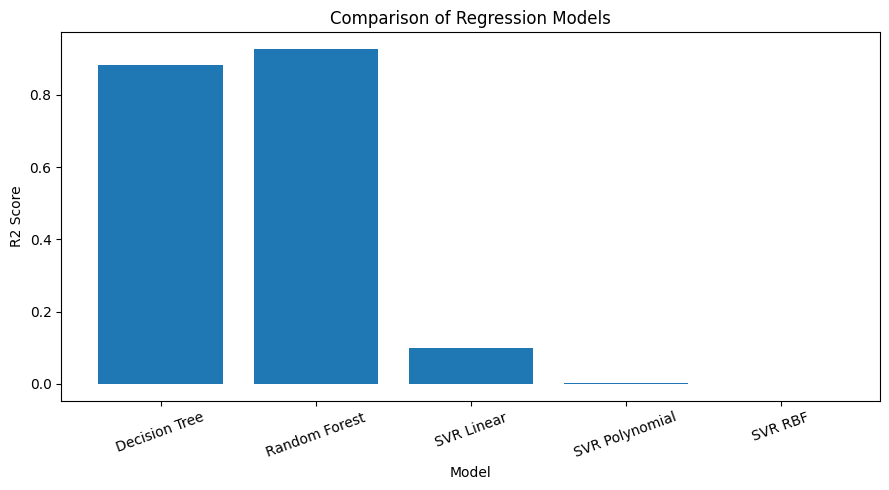

In [9]:
# PART F #

# 1 #

print("SVR - LINEAR KERNEL=")

svr_linear = make_pipeline(

    StandardScaler(),

    SVR(
        kernel="linear",
        C=100,
        epsilon=0.1
    )
)

svr_linear.fit(
    X_train,
    y_train
)

linear_prediction = svr_linear.predict(
    X_test
)

linear_mse = mean_squared_error(
    y_test,
    linear_prediction
)

linear_r2 = r2_score(
    y_test,
    linear_prediction
)

print("Linear SVR MSE:", linear_mse)

print("Linear SVR R2 :", linear_r2)

# 2 #

print("SVR - POLYNOMIAL KERNEL=")

svr_poly = make_pipeline(

    StandardScaler(),

    SVR(
        kernel="poly",
        C=100,
        epsilon=0.1,
        degree=3
    )
)

svr_poly.fit(
    X_train,
    y_train
)

poly_prediction = svr_poly.predict(
    X_test
)

poly_mse = mean_squared_error(
    y_test,
    poly_prediction
)

poly_r2 = r2_score(
    y_test,
    poly_prediction
)

print("Polynomial SVR MSE:", poly_mse)

print("Polynomial SVR R2 :", poly_r2)

print("SVR - RBF KERNEL")

svr_rbf = make_pipeline(

    StandardScaler(),

    SVR(
        kernel="rbf",
        C=100,
        gamma="scale",
        epsilon=0.1
    )
)

svr_rbf.fit(
    X_train,
    y_train
)

rbf_prediction = svr_rbf.predict(
    X_test
)

rbf_mse = mean_squared_error(
    y_test,
    rbf_prediction
)

rbf_r2 = r2_score(
    y_test,
    rbf_prediction
)

print("RBF SVR MSE:", rbf_mse)

print("RBF SVR R2 :", rbf_r2)

# 3 #
print("SVR HYPERPARAMETER TUNING=")


C_values = [1, 10, 100]

gamma_values = [
    "scale",
    0.01,
    0.1
]

epsilon_values = [
    0.1,
    0.2,
    0.5
]

best_score = -np.inf

best_parameters = None


for C in C_values:

    for gamma in gamma_values:

        for epsilon in epsilon_values:

            svr = make_pipeline(

                StandardScaler(),

                SVR(
                    kernel="rbf",
                    C=C,
                    gamma=gamma,
                    epsilon=epsilon
                )
            )

            svr.fit(
                X_train,
                y_train
            )

            prediction = svr.predict(
                X_test
            )

            score = r2_score(
                y_test,
                prediction
            )

            if score > best_score:

                best_score = score

                best_parameters = {
                    "C": C,
                    "gamma": gamma,
                    "epsilon": epsilon
                }


print("Best Parameters:")
print(best_parameters)

print("Best SVR R2:")
print(best_score)

# 4 #

print("FINAL MODEL COMPARISON")


final_comparison = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest",
        "SVR Linear",
        "SVR Polynomial",
        "SVR RBF"
    ],

    "MSE": [
        tree_test_mse,
        forest_test_mse,
        linear_mse,
        poly_mse,
        rbf_mse
    ],

    "R2 Score": [
        tree_r2,
        forest_r2,
        linear_r2,
        poly_r2,
        rbf_r2
    ]
})

print(final_comparison)

# FIND BEST MODEL

best_model = final_comparison.loc[
    final_comparison["R2 Score"].idxmax()
]

print("\n====================================")
print("BEST MODEL")
print("====================================")

print("Model:", best_model["Model"])

print("R2 Score:", best_model["R2 Score"])

print("MSE:", best_model["MSE"])


# ============================================================
# 25. PLOT MODEL R2 SCORES
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["R2 Score"]
)

plt.xlabel("Model")

plt.ylabel("R2 Score")

plt.title("Comparison of Regression Models")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [ ]:


import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ============================================================
# FUNCTION TO CALCULATE ALL METRICS
# ============================================================

def evaluate_model(model_name, train_pred, test_pred):

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    return [
        model_name,
        train_mse,
        test_mse,
        train_mae,
        test_mae,
        train_rmse,
        test_rmse,
        train_r2,
        test_r2
    ]


# ============================================================
# USE EXISTING MODELS
# ============================================================

results = []


# ---------------- RIDGE ----------------

results.append(
    evaluate_model(
        "Ridge",
        ridge.predict(X_train_scaled),
        ridge.predict(X_test_scaled)
    )
)


# ---------------- LASSO ----------------

results.append(
    evaluate_model(
        "Lasso",
        lasso.predict(X_train_scaled),
        lasso.predict(X_test_scaled)
    )
)


# ---------------- DECISION TREE ----------------

results.append(
    evaluate_model(
        "Decision Tree",
        tree.predict(X_train),
        tree.predict(X_test)
    )
)


# ---------------- RANDOM FOREST ----------------

results.append(
    evaluate_model(
        "Random Forest",
        forest.predict(X_train),
        forest.predict(X_test)
    )
)


# ---------------- SVR LINEAR ----------------

results.append(
    evaluate_model(
        "SVR Linear",
        svr_linear.predict(X_train),
        svr_linear.predict(X_test)
    )
)


# ---------------- SVR POLYNOMIAL ----------------

results.append(
    evaluate_model(
        "SVR Polynomial",
        svr_poly.predict(X_train),
        svr_poly.predict(X_test)
    )
)


# ---------------- SVR RBF ----------------

results.append(
    evaluate_model(
        "SVR RBF",
        svr_rbf.predict(X_train),
        svr_rbf.predict(X_test)
    )
)


# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Train MSE",
        "Test MSE",

        "Train MAE",
        "Test MAE",

        "Train RMSE",
        "Test RMSE",

        "Train R2",
        "Test R2"
    ]
)


# 1 # 

print("\n============================================")
print("QUESTION 22 : MODEL EVALUATION")
print("============================================")

q22_results = results_df[

    [
        "Model",
        "Test MSE",
        "Test MAE",
        "Test RMSE",
        "Test R2"
    ]

]

print(q22_results.round(4))

# 2 #
# ============================================================
# QUESTION 23
# COMPARE ALL MODELS
# ============================================================

print("\n============================================")
print("QUESTION 23 : MODEL COMPARISON")
print("============================================")

q23_results = results_df.sort_values(
    by="Test R2",
    ascending=False
)

print(
    q23_results[
        [
            "Model",
            "Test MSE",
            "Test MAE",
            "Test RMSE",
            "Test R2"
        ]
    ].round(4)
)


# BEST MODEL

best_model = results_df.loc[
    results_df["Test R2"].idxmax()
]

print("\nBEST MODEL")

print("Model :", best_model["Model"])
print("Test R2 :", round(best_model["Test R2"], 4))
print("Test RMSE :", round(best_model["Test RMSE"], 4))


# 3 #

print("\n============================================")
print("QUESTION 24 : OVERFITTING / UNDERFITTING")
print("============================================")


for index, row in results_df.iterrows():

    difference = row["Train R2"] - row["Test R2"]

    print("\n--------------------------------")
    print("Model:", row["Model"])

    print("Train R2:", round(row["Train R2"], 4))
    print("Test R2 :", round(row["Test R2"], 4))

    print("Difference:", round(difference, 4))


    if row["Train R2"] < 0.50 and row["Test R2"] < 0.50:

        print("Result: UNDERFITTING")


    elif difference > 0.10:

        print("Result: POSSIBLE OVERFITTING")


    else:

        print("Result: GOOD FIT")


QUESTION 22 : MODEL EVALUATION
            Model      Test MSE      Test MAE     Test RMSE  Test R2
0           Ridge  6.547397e+12  1.960022e+06  2.558788e+06   0.9187
1           Lasso  6.546053e+12  1.960177e+06  2.558525e+06   0.9187
2   Decision Tree  9.385836e+12  2.325304e+06  3.063631e+06   0.8835
3   Random Forest  5.886592e+12  1.778292e+06  2.426230e+06   0.9269
4      SVR Linear  7.261824e+13  6.620836e+06  8.521634e+06   0.0983
5  SVR Polynomial  8.025716e+13  6.974747e+06  8.958636e+06   0.0035
6         SVR RBF  8.056645e+13  6.984453e+06  8.975882e+06  -0.0004

QUESTION 23 : MODEL COMPARISON
            Model      Test MSE      Test MAE     Test RMSE  Test R2
3   Random Forest  5.886592e+12  1.778292e+06  2.426230e+06   0.9269
1           Lasso  6.546053e+12  1.960177e+06  2.558525e+06   0.9187
0           Ridge  6.547397e+12  1.960022e+06  2.558788e+06   0.9187
2   Decision Tree  9.385836e+12  2.325304e+06  3.063631e+06   0.8835
4      SVR Linear  7.261824e+13  6.6208

BEST PERFORMING MODEL
Model Name : Random Forest
Test MSE   : 5886592297013.36
Test MAE   : 1778291.6
Test RMSE  : 2426230.06
Test R2    : 0.9269
IMPACT OF REGULARIZATION
   Model      Test MSE      Test MAE     Test RMSE  Test R2
0  Ridge  6.547397e+12  1.960022e+06  2.558788e+06   0.9187
1  Lasso  6.546053e+12  1.960177e+06  2.558525e+06   0.9187
LINEAR VS NON-LINEAR COMPARISON
            Model      Test MSE      Test MAE     Test RMSE  Test R2
3   Random Forest  5.886592e+12  1.778292e+06  2.426230e+06   0.9269
1           Lasso  6.546053e+12  1.960177e+06  2.558525e+06   0.9187
0           Ridge  6.547397e+12  1.960022e+06  2.558788e+06   0.9187
2   Decision Tree  9.385836e+12  2.325304e+06  3.063631e+06   0.8835
4      SVR Linear  7.261824e+13  6.620836e+06  8.521634e+06   0.0983
5  SVR Polynomial  8.025716e+13  6.974747e+06  8.958636e+06   0.0035
6         SVR RBF  8.056645e+13  6.984453e+06  8.975882e+06  -0.0004


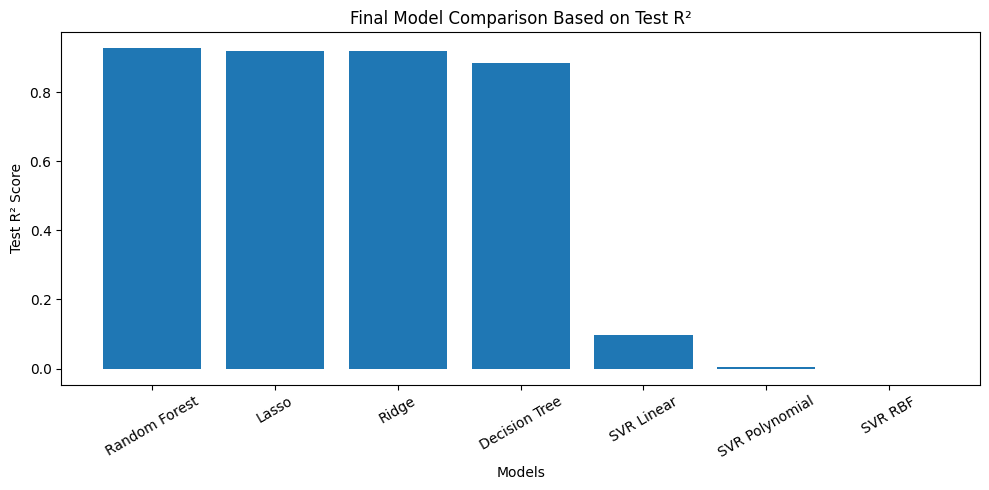

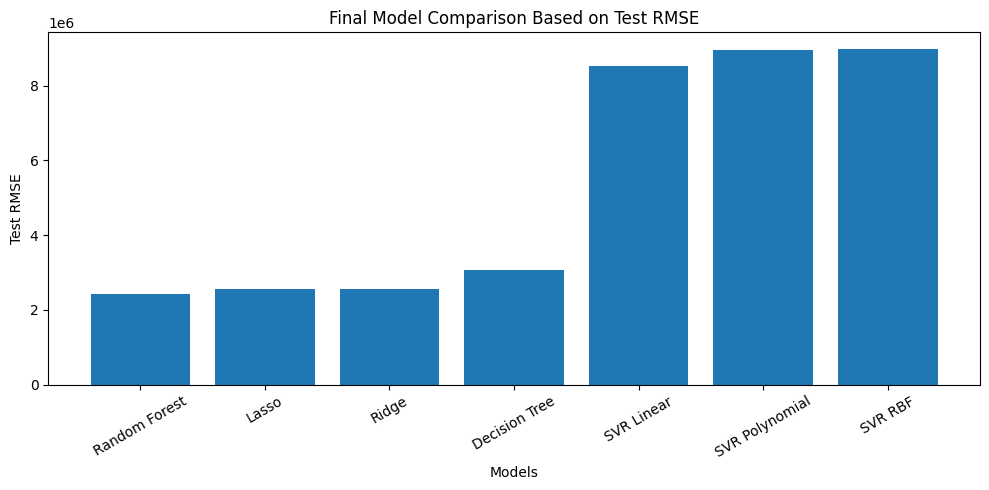


FINAL PROJECT CONCLUSION

1. The best-performing model is Random Forest.

2. It achieved a Test R² Score of
   0.9269.

3. Ridge and Lasso showed strong and stable performance,
   demonstrating the benefit of regularization.

4. Cross-validation helped evaluate model stability across
   different data splits.

5. Random Forest outperformed the single Decision Tree,
   showing the advantage of ensemble learning.

6. The SVR models showed weaker performance with the selected
   hyperparameters and require further tuning.

7. The final model can support house price estimation and
   real-estate business decision-making.



In [12]:
# PART H #

# 1 #

# BEST MODEL FROM PART G

best_model = results_df.loc[
    results_df["Test R2"].idxmax()
]

print("==========================================")
print("BEST PERFORMING MODEL")
print("==========================================")

print("Model Name :", best_model["Model"])
print("Test MSE   :", round(best_model["Test MSE"], 2))
print("Test MAE   :", round(best_model["Test MAE"], 2))
print("Test RMSE  :", round(best_model["Test RMSE"], 2))
print("Test R2    :", round(best_model["Test R2"], 4))

# 2 #

# ============================================================
# REGULARIZATION ANALYSIS
# ============================================================

regularization_results = results_df[
    results_df["Model"].isin(["Ridge", "Lasso"])
][
    [
        "Model",
        "Test MSE",
        "Test MAE",
        "Test RMSE",
        "Test R2"
    ]
]

print("==========================================")
print("IMPACT OF REGULARIZATION")
print("==========================================")

print(regularization_results.round(4))

# 4 #

# ============================================================
# LINEAR VS NON-LINEAR MODEL COMPARISON
# ============================================================

comparison = results_df[
    [
        "Model",
        "Test MSE",
        "Test MAE",
        "Test RMSE",
        "Test R2"
    ]
].sort_values(
    by="Test R2",
    ascending=False
)

print("==========================================")
print("LINEAR VS NON-LINEAR COMPARISON")
print("==========================================")

print(comparison.round(4))

# FINAL PLOT 1 #

import matplotlib.pyplot as plt


# ============================================================
# R2 SCORE COMPARISON
# ============================================================

plot_data = results_df.sort_values(
    by="Test R2",
    ascending=False
)

plt.figure(figsize=(10, 5))

plt.bar(
    plot_data["Model"],
    plot_data["Test R2"]
)

plt.xlabel("Models")

plt.ylabel("Test R² Score")

plt.title("Final Model Comparison Based on Test R²")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

# FINAL PLOT 2 #

# ============================================================
# RMSE COMPARISON
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    plot_data["Model"],
    plot_data["Test RMSE"]
)

plt.xlabel("Models")

plt.ylabel("Test RMSE")

plt.title("Final Model Comparison Based on Test RMSE")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

# FINAL CONCLUSION

print("\n==========================================")
print("FINAL PROJECT CONCLUSION")
print("==========================================")

print(
    f"""
1. The best-performing model is {best_model["Model"]}.

2. It achieved a Test R² Score of
   {best_model["Test R2"]:.4f}.

3. Ridge and Lasso showed strong and stable performance,
   demonstrating the benefit of regularization.

4. Cross-validation helped evaluate model stability across
   different data splits.

5. Random Forest outperformed the single Decision Tree,
   showing the advantage of ensemble learning.

6. The SVR models showed weaker performance with the selected
   hyperparameters and require further tuning.

7. The final model can support house price estimation and
   real-estate business decision-making.
"""
)

